In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [3]:
df = pd.read_csv("winequality-red.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df.shape

(1599, 12)

In [8]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [12]:
X=df.drop('quality',axis=1)
y=df['quality']

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
model = RandomForestRegressor(n_estimators=100,max_depth=10,n_jobs=-1,random_state=42)

In [23]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred=model.predict(X_test)
y_pred

array([5.3221628 , 5.09719423, 5.45312705, 5.20511087, 5.94493316,
       5.10567137, 5.16766413, 4.95452459, 6.10882262, 5.92710265,
       6.68915104, 5.31634849, 5.65354691, 5.2383012 , 5.47496002,
       6.32462677, 5.35222771, 5.76613232, 6.88434373, 5.14352608,
       4.92624385, 5.64301984, 5.39303581, 5.961387  , 5.53810764,
       5.85763196, 6.43069247, 5.31614809, 5.26929102, 5.97600621,
       5.33266543, 5.42552045, 5.8610272 , 5.39154797, 5.68949613,
       5.10253974, 6.17946031, 6.0387212 , 5.47506593, 6.05425689,
       5.20346423, 5.20522678, 6.27217426, 5.10033855, 5.60373321,
       5.70855451, 6.34473664, 5.646244  , 5.20937421, 5.65070168,
       5.06349952, 5.26438905, 5.60008055, 7.13497881, 5.22417213,
       5.6015751 , 5.9678247 , 5.90994726, 5.5754751 , 5.12314889,
       5.71540864, 6.24056376, 5.342237  , 5.24958183, 6.74285786,
       5.20925924, 6.67119508, 5.55807243, 6.64021135, 5.37816039,
       6.10183563, 5.1664497 , 5.73724063, 5.61088528, 6.09831

In [25]:
print("MSE:",mean_squared_error(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("r2_score:",r2_score(y_test,y_pred))

MSE: 0.3181876065176874
MAE: 0.4447183253946186
r2_score: 0.5131067274255265


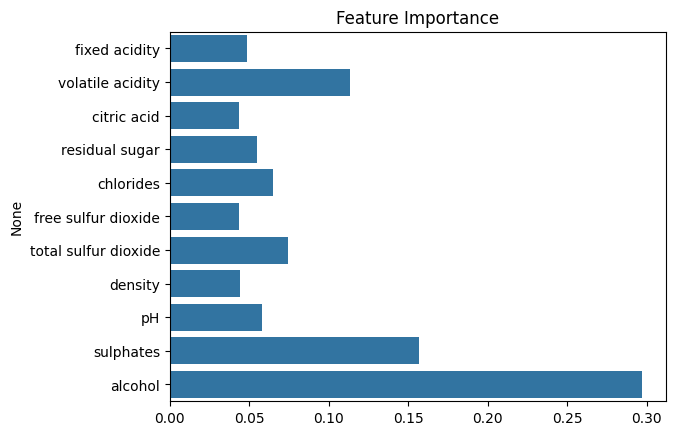

In [26]:
importance = model.feature_importances_

sns.barplot(x=importance, y=X.columns)

plt.title("Feature Importance")
plt.show()